In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import pandas as pd
import numpy as np
from google.colab import files

In [2]:
uploaded = files.upload()

Saving joshia's validation_predictions.csv to joshia's validation_predictions.csv
Saving test_labels.csv to test_labels.csv
Saving train_labels.csv to train_labels.csv


In [3]:
train_labels = pd.read_csv("train_labels.csv")
test_labels = pd.read_csv("test_labels.csv")

# Training data

In [4]:
train_labels

,image_name,patient_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
0,ISIC_0015719,IP_3075186,female,45.0,upper extremity,unknown,benign,0
1,ISIC_0074542,IP_4698288,male,25.0,lower extremity,unknown,benign,0
2,ISIC_0076545,IP_9802602,male,55.0,upper extremity,unknown,benign,0
3,ISIC_0082348,IP_7684360,male,55.0,torso,unknown,benign,0
4,ISIC_0085172,IP_1705144,female,50.0,lower extremity,unknown,benign,0
...,...,...,...,...,...,...,...,...
6859,ISIC_9988492,IP_8173459,female,50.0,torso,unknown,benign,0
6860,ISIC_9990676,IP_3686214,female,55.0,lower extremity,nevus,benign,0
6861,ISIC_9991394,IP_2321962,female,30.0,torso,unknown,benign,0
6862,ISIC_9991967,IP_2507276,male,70.0,lower extremity,nevus,benign,0


In [5]:
print(f"Number of malignant cases: {len(train_labels[train_labels["target"] == 1])}")

Number of malignant cases: 128


In [6]:
train_labels.describe()

,age_approx,target
count,6864.000000,6864.000000
mean,48.944493,0.018648
std,14.401600,0.135288
min,15.000000,0.000000
25%,40.000000,0.000000
50%,50.000000,0.000000
75%,60.000000,0.000000
max,90.000000,1.000000


In [7]:
train_labels.isna().sum()

,0
image_name,0
patient_id,0
sex,0
age_approx,0
anatom_site_general_challenge,196
diagnosis,0
benign_malignant,0
target,0


In [8]:
print(f"Number of unique patients: {len(train_labels) - train_labels["patient_id"].duplicated().sum()}")

Number of unique patients: 422


In [9]:
print(f"Does every 'melanoma' diagnosis correspond to a '1' in a target: {(train_labels[train_labels["diagnosis"] == "melanoma"]["target"] == 1).all()}")

Does every 'melanoma' diagnosis correspond to a '1' in a target: True


Testing data

In [10]:
test_labels

,image_name,patient_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
0,ISIC_0088489,IP_9147454,female,55.0,torso,unknown,benign,0
1,ISIC_0096201,IP_9906695,female,45.0,torso,nevus,benign,0
2,ISIC_0097500,IP_9147454,female,55.0,upper extremity,unknown,benign,0
3,ISIC_0112444,IP_9147454,female,55.0,torso,unknown,benign,0
4,ISIC_0148465,IP_1517386,male,40.0,head/neck,unknown,benign,0
...,...,...,...,...,...,...,...,...
1983,ISIC_9981394,IP_8352243,female,40.0,upper extremity,unknown,benign,0
1984,ISIC_9998152,IP_4356379,female,40.0,lower extremity,unknown,benign,0
1985,ISIC_9998682,IP_2516168,male,60.0,head/neck,melanoma,malignant,1
1986,ISIC_9999127,IP_9583707,male,20.0,torso,unknown,benign,0


In [11]:
print(f"Number of malignant cases: {len(test_labels[test_labels["target"] == 1])}")

Number of malignant cases: 31


In [12]:
test_labels.describe()

,age_approx,target
count,1988.000000,1988.000000
mean,50.364688,0.015594
std,14.808977,0.123928
min,10.000000,0.000000
25%,40.000000,0.000000
50%,50.000000,0.000000
75%,60.000000,0.000000
max,90.000000,1.000000


In [13]:
test_labels.isna().sum()

,0
image_name,0
patient_id,0
sex,0
age_approx,0
anatom_site_general_challenge,24
diagnosis,0
benign_malignant,0
target,0


In [14]:
print(f"Number of unique patients: {len(test_labels) - test_labels["patient_id"].duplicated().sum()}")

Number of unique patients: 106


In [15]:
print(f"Does every 'melanoma' diagnosis correspond to a '1' in a target: {(test_labels[test_labels["diagnosis"] == "melanoma"]["target"] == 1).all()}")

Does every 'melanoma' diagnosis correspond to a '1' in a target: True


In [16]:
train_patients = set(train_labels['patient_id'])
test_patients = set(test_labels['patient_id'])
overlap = train_patients & test_patients
print(len(overlap))

0


Text(0.5, 1.0, 'Age Distribution: Benign vs Malignant')

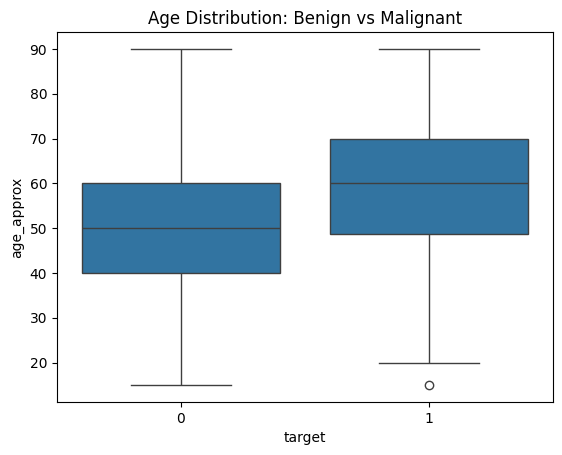

In [17]:
# Malignant cases show a visibly higher median age than benign cases in this boxplot.
sns.boxplot(data=train_labels, x='target', y='age_approx').set_title("Age Distribution: Benign vs Malignant")

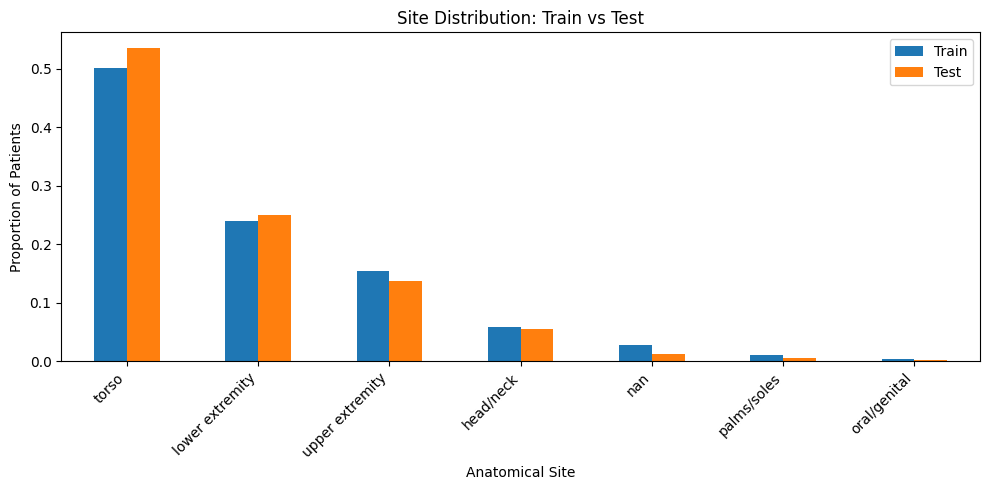

In [18]:
# Site distribution
train_site_pct = train_labels['anatom_site_general_challenge'].value_counts(normalize=True, dropna=False).rename('Train')
test_site_pct = test_labels['anatom_site_general_challenge'].value_counts(normalize=True, dropna=False).rename('Test')

site_comparison = pd.concat([train_site_pct, test_site_pct], axis=1).fillna(0)
site_comparison = site_comparison.sort_values('Train', ascending=False)

site_comparison.plot.bar(
    figsize=(10, 5),
    xlabel="Anatomical Site",
    ylabel="Proportion of Patients",
    title="Site Distribution: Train vs Test"
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Hypothesis testing: Seeing if having a malignant region increases the chances of having more malignant spots

In [19]:
unique_patients = train_labels.groupby("patient_id")["target"].agg(["sum", "count"])
unique_patients.describe()

,sum,count
count,422.000000,422.000000
mean,0.303318,16.265403
std,0.756877,16.568455
min,0.000000,3.000000
25%,0.000000,5.000000
50%,0.000000,12.000000
75%,0.000000,21.750000
max,8.000000,115.000000


In [20]:
# Patients who have 115 entries
unique_patients[unique_patients['count'] == 115]

,sum,count
patient_id,,
IP_4382720,0,115
IP_4938382,1,115


In [21]:
# Patients with more than 1 melanoma spot
unique_patients[unique_patients['sum'] > 1]

,sum,count
patient_id,,
IP_0957064,2,3
IP_1023029,2,38
IP_1122600,2,16
IP_1512731,2,37
IP_2101945,2,17
IP_2412574,5,23
IP_2986217,3,7
IP_3010556,3,4
IP_3045056,2,4


<Axes: title={'center': 'Melanoma Patients Count by Sum'}, xlabel='Melanoma Counts', ylabel='Number of patients'>

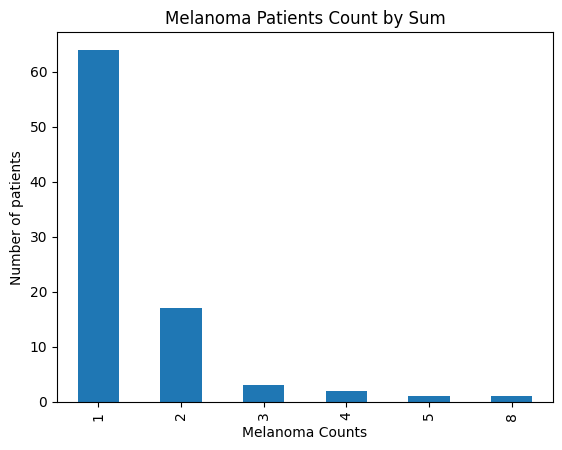

In [22]:
melanoma_patients = unique_patients[unique_patients['sum'] > 0]
melanoma_patients.groupby("sum")["sum"].count().plot.bar(
    xlabel = "Melanoma Counts",
    ylabel = "Number of patients",
    title = "Melanoma Patients Count by Sum"
)

In [23]:
n_simulations = 10000
p = train_labels['target'].mean()  # overall per-lesion malignancy rate
lesion_counts = unique_patients['count'].values

rng = np.random.default_rng(42)
simulated_counts = []

for _ in range(n_simulations):
    sim_malignant_per_patient = rng.binomial(lesion_counts, p)
    simulated_counts.append((sim_malignant_per_patient > 1).sum())

simulated_counts = np.array(simulated_counts)
p_value = (simulated_counts >= 24).mean()

print(f"P-value: {p_value:.4f}")
print(f"Simulated mean: {simulated_counts.mean():.2f}, std: {simulated_counts.std():.2f}")

P-value: 0.3075
Simulated mean: 21.52, std: 4.07


We found no statistically significant evidence of within-patient melanoma clustering beyond what independent lesion-level risk would predict (p=0.31, simulation-based test accounting for each patient's lesion count). This means this dataset doesn't provide strong enough evidence to detect one, if it exists

# Preprocessing

In [24]:
missing_site = train_labels[train_labels["anatom_site_general_challenge"].isna()]
print(f"Missing site malignancy rate: {len(missing_site[missing_site["target"] == 1]) / len(missing_site) * 100: .4f}")
recorded_site = train_labels[train_labels["anatom_site_general_challenge"].notna()]
print(f"Recorded site malignancy rate: {len(recorded_site[recorded_site["target"] == 1]) / len(recorded_site) * 100: .4f}")

Missing site malignancy rate:  1.0204
Recorded site malignancy rate:  1.8896


Missing-site rows show a lower raw malignancy rate than recorded-site rows (1.02% vs 1.89%), but a chi-square test found this difference is NOT statistically significant (p=0.5361) with only 196 missing rows, this test likely lacks power to detect a real but modest effect.
We cannot confirm independence, so rather than assume missingness is random (which dropping or mean-imputing would implicitly assume), we keep "missing" as its own explicit category which is the conservative choice when missing-data randomness hasn't been established either way.

In [25]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(train_labels['anatom_site_general_challenge'].isna(), train_labels['target'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(train_labels.groupby(train_labels['anatom_site_general_challenge'].isna())['target'].mean())
print(f"Chi-square p-value: {p:.4f}")

anatom_site_general_challenge
False    0.018896
True     0.010204
Name: target, dtype: float64
Chi-square p-value: 0.5361


In [26]:
train_labels_clean = train_labels.copy()
train_labels_clean["sex"] = train_labels["sex"].map({"male": 1, "female": 0})
train_labels_clean["anatom_site_general_challenge"] = train_labels_clean["anatom_site_general_challenge"].fillna("missing")
train_labels_clean = train_labels_clean.drop(["diagnosis", "benign_malignant"], axis=1)
train_labels_clean

,image_name,patient_id,sex,age_approx,anatom_site_general_challenge,target
0,ISIC_0015719,IP_3075186,0,45.0,upper extremity,0
1,ISIC_0074542,IP_4698288,1,25.0,lower extremity,0
2,ISIC_0076545,IP_9802602,1,55.0,upper extremity,0
3,ISIC_0082348,IP_7684360,1,55.0,torso,0
4,ISIC_0085172,IP_1705144,0,50.0,lower extremity,0
...,...,...,...,...,...,...
6859,ISIC_9988492,IP_8173459,0,50.0,torso,0
6860,ISIC_9990676,IP_3686214,0,55.0,lower extremity,0
6861,ISIC_9991394,IP_2321962,0,30.0,torso,0
6862,ISIC_9991967,IP_2507276,1,70.0,lower extremity,0


# Modeling

## Logistic Regression

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder

# Split by patient (not row) to prevent one patient's lesions spanning train/val (leakage).
# Also stratify by whether each patient has ANY malignant lesion, since an unstratified
# split previously produced a skewed val set (1.26% malignant vs 2.06% in train) --
# stratifying brought both sets to ~1.8-2.0%, making evaluation trustworthy.
patient_summary = train_labels_clean.groupby('patient_id')['target'].max()
train_patients, val_patients = train_test_split(patient_summary.index, test_size=0.2, random_state=80, stratify=patient_summary.values)

train_df = train_labels_clean[train_labels_clean['patient_id'].isin(train_patients)]
val_df = train_labels_clean[train_labels_clean['patient_id'].isin(val_patients)]

X_train = train_df.drop(columns=["image_name", "patient_id", "target"])
y_train = train_df["target"]
X_val = val_df.drop(columns=["image_name", "patient_id", "target"])
y_val = val_df["target"]

# One-hot encode site, fit on train only, apply to both
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
train_site_encoded = encoder.fit_transform(X_train[['anatom_site_general_challenge']])
val_site_encoded = encoder.transform(X_val[['anatom_site_general_challenge']])

site_cols = encoder.get_feature_names_out(['anatom_site_general_challenge'])
X_train = pd.concat([
    X_train.drop(columns=['anatom_site_general_challenge']).reset_index(drop=True),
    pd.DataFrame(train_site_encoded, columns=site_cols)
], axis=1)
X_val = pd.concat([
    X_val.drop(columns=['anatom_site_general_challenge']).reset_index(drop=True),
    pd.DataFrame(val_site_encoded, columns=site_cols)
], axis=1)

# Standardize age_approx so its coefficient is on a comparable scale to the 0/1 site columns.
# Before standardizing, age's raw coefficient (0.041) looked negligible purely due to units
# (1 year vs a full 0-to-1 category jump) -- after scaling, it rose to 0.396, though it's
# still below several site coefficients. See age-binning analysis below for why: logistic
# regression's linear coefficient understates age because the real relationship is
# threshold-like (~flat below 60, then rising sharply), which Random Forest captures better.

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train['age_approx'] = scaler.fit_transform(X_train[['age_approx']])
X_val['age_approx'] = scaler.transform(X_val[['age_approx']])

clf = LogisticRegression(max_iter=1000, random_state=0, class_weight='balanced')
clf.fit(X_train, y_train)

y_pred = clf.predict(X_val)
y_pred_proba = clf.predict_proba(X_val)[:, 1]


In [28]:
print(f"Train malignant rate: {y_train.mean():.4f}")
print(f"Val malignant rate:   {y_val.mean():.4f}")

Train malignant rate: 0.0183
Val malignant rate:   0.0202


In [29]:
print(f"Train: {y_train.sum()} malignant / {len(y_train)} total")
print(f"Val:   {y_val.sum()} malignant / {len(y_val)} total")

Train: 103 malignant / 5629 total
Val:   25 malignant / 1235 total


ROC-AUC and PR-AUC used instead of accuracy: with ~1.9% malignant rate, a model predicting "benign" for everything would score ~98% accuracy while being clinically useless.
PR-AUC matters more here than ROC-AUC, since it specifically reflects how well the model finds the rare positive (malignant) cases without excessive false positives.

ROC-AUC: 0.6809
PR-AUC:  0.0486

Confusion Matrix:
[[706 504]
 [  8  17]]

Classification Report:
              precision    recall  f1-score   support

      benign       0.99      0.58      0.73      1210
   malignant       0.03      0.68      0.06        25

    accuracy                           0.59      1235
   macro avg       0.51      0.63      0.40      1235
weighted avg       0.97      0.59      0.72      1235



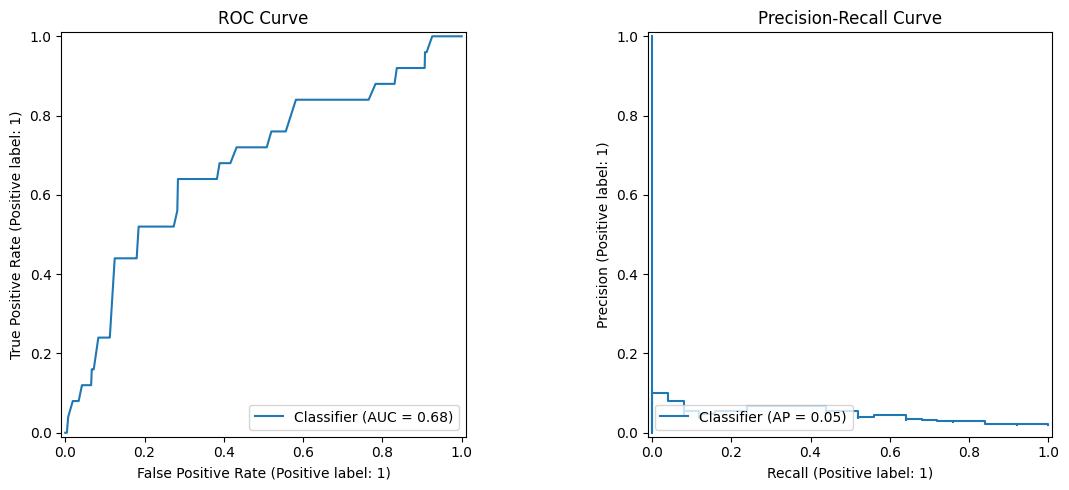

In [30]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay
)

roc_auc = roc_auc_score(y_val, y_pred_proba)
pr_auc = average_precision_score(y_val, y_pred_proba)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=["benign", "malignant"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_predictions(y_val, y_pred_proba, ax=axes[0])
axes[0].set_title("ROC Curve")
PrecisionRecallDisplay.from_predictions(y_val, y_pred_proba, ax=axes[1])
axes[1].set_title("Precision-Recall Curve")
plt.tight_layout()
plt.show()

Coefficients ranked by raw magnitude. Palms/soles and oral/genital dominate, but these categories have small sample sizes (n=70, n=33 respectively, see value_counts check), so their large coefficients are somewhat less stable than torso's (n=3440).
They did hold up consistently across two different train/val splits, which is reassuring, but should still be reported with that caveat.

In [31]:
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': clf.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)
print(coef_df)

                                         feature  coefficient
6      anatom_site_general_challenge_palms/soles    -2.423381
5     anatom_site_general_challenge_oral/genital     2.182804
4          anatom_site_general_challenge_missing    -1.081574
2        anatom_site_general_challenge_head/neck     1.021185
0                                            sex     0.497101
1                                     age_approx     0.395958
7            anatom_site_general_challenge_torso    -0.154561
8  anatom_site_general_challenge_upper extremity     0.067944
3  anatom_site_general_challenge_lower extremity     0.047515


Checking sample sizes behind the largest coefficients above, since a large coefficient from a small category (e.g. palms/soles, oral/genital) is less trustworthy than one estimated from thousands of rows like torso.

In [32]:
train_labels_clean['anatom_site_general_challenge'].value_counts()

,count
anatom_site_general_challenge,
torso,3440
lower extremity,1650
upper extremity,1066
head/neck,409
missing,196
palms/soles,70
oral/genital,33


## Dummy

In [33]:
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy='stratified', random_state=0)
dummy.fit(X_train, y_train)
dummy_proba = dummy.predict_proba(X_val)[:, 1]
print(f"Dummy ROC-AUC: {roc_auc_score(y_val, dummy_proba):.4f}")
print(f"Dummy PR-AUC:  {average_precision_score(y_val, dummy_proba):.4f}")

Dummy ROC-AUC: 0.4905
Dummy PR-AUC:  0.0202


## Random Forest

In [34]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=0)
rf.fit(X_train, y_train)
rf_proba = rf.predict_proba(X_val)[:, 1]
print(f"RF ROC-AUC: {roc_auc_score(y_val, rf_proba):.4f}")
print(f"RF PR-AUC:  {average_precision_score(y_val, rf_proba):.4f}")

RF ROC-AUC: 0.6339
RF PR-AUC:  0.0629


age_approx dominates RF's importance (0.687) far more than its logistic regression coefficient suggests. This is explained by the age-binning analysis below: the malignancy rate is roughly flat below age 60 then rises sharply after which is a non-linear, threshold-like pattern that tree splits capture naturally but a single linear coefficient must average across, understating its true importance.

In [35]:
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)
print(importances)

                                         feature  importance
1                                     age_approx    0.687052
0                                            sex    0.095164
2        anatom_site_general_challenge_head/neck    0.056615
7            anatom_site_general_challenge_torso    0.037825
3  anatom_site_general_challenge_lower extremity    0.037008
8  anatom_site_general_challenge_upper extremity    0.030804
5     anatom_site_general_challenge_oral/genital    0.030490
4          anatom_site_general_challenge_missing    0.016509
6      anatom_site_general_challenge_palms/soles    0.008534


Age-binning: reveals malignancy rate stays flat (~1-1.5%) below age 60, then rises sharply to 4.6-6.6% in older brackets. This confirms the non-linear relationship hypothesized above from the LR/RF disagreement on age's importance.

In [36]:
train_labels_clean['age_bin'] = pd.cut(train_labels_clean['age_approx'], bins=[0,30,45,60,75,100])
train_labels_clean.groupby('age_bin')['target'].mean()

/tmp/ipykernel_1321/4107088436.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_labels_clean.groupby('age_bin')['target'].mean()


,target
age_bin,
"(0, 30]",0.012004
"(30, 45]",0.009472
"(45, 60]",0.015099
"(60, 75]",0.045752
"(75, 100]",0.066116


Random Forest's feature importance showed age_approx dominating (0.687) far more than logistic regression's coefficient suggested (0.396 after standardizing), and age-binning analysis confirmed why: malignancy rate stays flat below age 60 (~1-1.5%) then rises sharply after (4.6-6.6%) which is a non-linear, threshold-like pattern that a single linear coefficient can't represent well.
Engineering an explicit age_over_60 flag tests whether giving logistic regression direct access to this threshold closes the gap with RF.

In [37]:
train_labels_clean["age_over_60"] = np.where(train_labels_clean["age_approx"] >= 60, 1, 0)

train_df2 = train_labels_clean[train_labels_clean['patient_id'].isin(train_patients)]
val_df2 = train_labels_clean[train_labels_clean['patient_id'].isin(val_patients)]

X_train2 = train_df2.drop(columns=["image_name", "patient_id", "target", "age_bin"])
y_train2 = train_df2["target"]
X_val2 = val_df2.drop(columns=["image_name", "patient_id", "target", "age_bin"])
y_val2 = val_df2["target"]

encoder2 = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
train_site_encoded2 = encoder2.fit_transform(X_train2[['anatom_site_general_challenge']])
val_site_encoded2 = encoder2.transform(X_val2[['anatom_site_general_challenge']])

site_cols2 = encoder2.get_feature_names_out(['anatom_site_general_challenge'])
X_train2 = pd.concat([
    X_train2.drop(columns=['anatom_site_general_challenge']).reset_index(drop=True),
    pd.DataFrame(train_site_encoded2, columns=site_cols2)
], axis=1)
X_val2 = pd.concat([
    X_val2.drop(columns=['anatom_site_general_challenge']).reset_index(drop=True),
    pd.DataFrame(val_site_encoded2, columns=site_cols2)
], axis=1)

scaler2 = StandardScaler()
X_train2['age_approx'] = scaler2.fit_transform(X_train2[['age_approx']])
X_val2['age_approx'] = scaler2.transform(X_val2[['age_approx']])

clf2 = LogisticRegression(max_iter=1000, random_state=0, class_weight='balanced')
clf2.fit(X_train2, y_train2)

y_pred2 = clf2.predict(X_val2)
y_pred_proba2 = clf2.predict_proba(X_val2)[:, 1]

print(f"ROC-AUC: {roc_auc_score(y_val2, y_pred_proba2):.4f}")
print(f"PR-AUC:  {average_precision_score(y_val2, y_pred_proba2):.4f}")

ROC-AUC: 0.6749
PR-AUC:  0.0509


Adding an explicit age-over-60 threshold feature to logistic regression did not meaningfully change performance (ROC-AUC 0.681→0.675, PR-AUC 0.049→0.051), suggesting the model was already implicitly weighting older age through its existing continuous age coefficient. This supports Random Forest's structural advantage on this feature. The tree-based model captures the non-linear threshold directly through splits, rather than needing it engineered as an explicit input.

## XGBoost

In [38]:
from xgboost import XGBClassifier

# scale_pos_weight approximates class_weight='balanced' for XGBoost:
# ratio of negative to positive samples in training data
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=200,
    scale_pos_weight=scale_pos_weight,
    random_state=0,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)

xgb_proba = xgb.predict_proba(X_val)[:, 1]
print(f"XGBoost ROC-AUC: {roc_auc_score(y_val, xgb_proba):.4f}")
print(f"XGBoost PR-AUC:  {average_precision_score(y_val, xgb_proba):.4f}")

XGBoost ROC-AUC: 0.6305
XGBoost PR-AUC:  0.0406


In [39]:
xgb_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False)
print(xgb_importances)

                                         feature  importance
6      anatom_site_general_challenge_palms/soles    0.194504
2        anatom_site_general_challenge_head/neck    0.175262
3  anatom_site_general_challenge_lower extremity    0.120526
1                                     age_approx    0.116907
5     anatom_site_general_challenge_oral/genital    0.106382
7            anatom_site_general_challenge_torso    0.092835
8  anatom_site_general_challenge_upper extremity    0.082648
0                                            sex    0.059151
4          anatom_site_general_challenge_missing    0.051784


In [40]:
xgb.get_booster().get_score(importance_type='weight')

{'sex': 481.0,
 'age_approx': 1473.0,
 'anatom_site_general_challenge_head/neck': 87.0,
 'anatom_site_general_challenge_lower extremity': 154.0,
 'anatom_site_general_challenge_missing': 88.0,
 'anatom_site_general_challenge_oral/genital': 105.0,
 'anatom_site_general_challenge_palms/soles': 19.0,
 'anatom_site_general_challenge_torso': 113.0,
 'anatom_site_general_challenge_upper extremity': 183.0}

# Fusion Model

In [41]:
validation_set = val_df.copy()

In [42]:
training_set = train_df.copy()

In [43]:
validation_set = validation_set.drop(["patient_id", "sex", "age_approx", "anatom_site_general_challenge", "target"], axis=1)
validation_set

,image_name
3,ISIC_0082348
14,ISIC_0109869
43,ISIC_0179191
53,ISIC_0192419
55,ISIC_0196399
...,...
6841,ISIC_9967383
6842,ISIC_9969263
6844,ISIC_9971202
6855,ISIC_9985141


In [44]:
training_set = training_set.drop(["patient_id", "sex", "age_approx", "anatom_site_general_challenge", "target"], axis=1)
training_set

,image_name
0,ISIC_0015719
1,ISIC_0074542
2,ISIC_0076545
4,ISIC_0085172
5,ISIC_0086349
...,...
6859,ISIC_9988492
6860,ISIC_9990676
6861,ISIC_9991394
6862,ISIC_9991967


In [45]:
validation_set.to_csv('validation_set.csv', index=False)

In [46]:
training_set.to_csv("training_set.csv", index=False)

# Fusion Model

In [47]:
image_predictions = pd.read_csv("joshia's validation_predictions.csv")
image_predictions

,image_name,probability
0,ISIC_0082348,0.064600
1,ISIC_0109869,0.129595
2,ISIC_0179191,0.070779
3,ISIC_0192419,0.066767
4,ISIC_0196399,0.951879
...,...,...
1230,ISIC_9967383,0.304340
1231,ISIC_9969263,0.086935
1232,ISIC_9971202,0.093296
1233,ISIC_9985141,0.069506


In [48]:
random_forest_prob = pd.DataFrame({
    'image_name': val_df['image_name'].values,
    'rf_probability': rf_proba
})

fusion_df = image_predictions.merge(random_forest_prob, on='image_name', how='inner')
fusion_df = fusion_df.rename(columns={'probability': 'image_probability'})

# Verify nothing was silently dropped or duplicated
assert len(fusion_df) == len(val_df), f"Row count mismatch: {len(fusion_df)} vs {len(val_df)}"
print(f"Merged {len(fusion_df)} rows successfully")

Merged 1235 rows successfully


In [49]:
fusion_df

,image_name,image_probability,rf_probability
0,ISIC_0082348,0.064600,0.191406
1,ISIC_0109869,0.129595,0.733271
2,ISIC_0179191,0.070779,0.000000
3,ISIC_0192419,0.066767,0.277490
4,ISIC_0196399,0.951879,0.000000
...,...,...,...
1230,ISIC_9967383,0.304340,0.662524
1231,ISIC_9969263,0.086935,0.191406
1232,ISIC_9971202,0.093296,0.012539
1233,ISIC_9985141,0.069506,0.000000


In [51]:
# 1. Simple average
fusion_df['avg_proba'] = (fusion_df['image_probability'] + fusion_df['rf_probability']) / 2

# 2. Weighted average — sweep weights, pick best by PR-AUC on validation
best_w, best_pr_auc = 0, 0
for w in np.arange(0, 1.05, 0.05):
    weighted = w * fusion_df['image_probability'] + (1 - w) * fusion_df['rf_probability']
    pr = average_precision_score(y_val, weighted)
    if pr > best_pr_auc:
        best_pr_auc, best_w = pr, w
print(f"Best image-model weight: {best_w:.2f}, PR-AUC: {best_pr_auc:.4f}")
fusion_df['weighted_proba'] = best_w * fusion_df['image_probability'] + (1 - best_w) * fusion_df['rf_probability']

# 3. Logistic Regression
meta_features = fusion_df[['image_probability', 'rf_probability']].values
lr_fusion = LogisticRegression()
lr_fusion.fit(meta_features, y_val)
fusion_df['lr_proba'] = lr_fusion.predict_proba(meta_features)[:, 1]

# Compare all approaches
for col in ['image_probability', 'rf_probability', 'avg_proba', 'weighted_proba', 'lr_proba']:
    roc = roc_auc_score(y_val, fusion_df[col])
    pr = average_precision_score(y_val, fusion_df[col])
    print(f"{col:20s} ROC-AUC: {roc:.4f}  PR-AUC: {pr:.4f}")

Best image-model weight: 0.85, PR-AUC: 0.1230
image_probability    ROC-AUC: 0.8306  PR-AUC: 0.1132
rf_probability       ROC-AUC: 0.6339  PR-AUC: 0.0629
avg_proba            ROC-AUC: 0.7932  PR-AUC: 0.0978
weighted_proba       ROC-AUC: 0.8592  PR-AUC: 0.1230
lr_proba             ROC-AUC: 0.8625  PR-AUC: 0.1211


In [52]:
fusion_df = fusion_df.merge(val_df[['image_name', 'age_approx', 'sex']], on='image_name', how='inner')

meta_features_extended = fusion_df[['image_probability', 'rf_probability', 'age_approx', 'sex']].values
lr_extended = LogisticRegression()
lr_extended.fit(meta_features_extended, y_val)
fusion_df['lr_extended_proba'] = lr_extended.predict_proba(meta_features_extended)[:, 1]

print(f"Logistic Regression Extended ROC-AUC: {roc_auc_score(y_val, fusion_df['lr_extended_proba']):.4f}")
print(f"Logistic Regression Extended PR-AUC:  {average_precision_score(y_val, fusion_df['lr_extended_proba']):.4f}")

Logistic Regression Extended ROC-AUC: 0.8554
Logistic Regression Extended PR-AUC:  0.1922


In [53]:
rf_fusion = RandomForestClassifier(n_estimators=100, max_depth=3, class_weight='balanced', random_state=0)
rf_fusion.fit(meta_features, y_val)  # or meta_features_rich
fusion_df['rf_extended_proba'] = rf_fusion.predict_proba(meta_features)[:, 1]
print(f"Random Forest ROC-AUC: {roc_auc_score(y_val, fusion_df['rf_extended_proba']):.4f}")
print(f"Random Forest PR-AUC: {average_precision_score(y_val, fusion_df['rf_extended_proba']):.4f}")

Random Forest ROC-AUC: 0.9463
Random Forest PR-AUC: 0.4461


Cross validation prediction

In [55]:
from sklearn.model_selection import cross_val_predict

# Logistic Regression CV (image + rf probabilities only)
lr_basic_cv = cross_val_predict(LogisticRegression(), meta_features, y_val, cv=5, method='predict_proba')[:, 1]
print(f"CV Logistic Regression ROC-AUC: {roc_auc_score(y_val, lr_basic_cv):.4f}  PR-AUC: {average_precision_score(y_val, lr_basic_cv):.4f}")

# Logistic Regression Extended CV (+ age, sex)
lr_extended_cv = cross_val_predict(LogisticRegression(), meta_features_extended, y_val, cv=5, method='predict_proba')[:, 1]
print(f"CV Logistic Regression Extended ROC-AUC: {roc_auc_score(y_val, lr_extended_cv):.4f}  PR-AUC: {average_precision_score(y_val, lr_extended_cv):.4f}")

# RF CV
rf_cv = cross_val_predict(rf_fusion, meta_features, y_val, cv=5, method='predict_proba')[:, 1]
print(f"CV RF ROC-AUC: {roc_auc_score(y_val, rf_cv):.4f}  PR-AUC: {average_precision_score(y_val, rf_cv):.4f}")

CV Logistic Regression ROC-AUC: 0.8539  PR-AUC: 0.1136
CV Logistic Regression Extended ROC-AUC: 0.8285  PR-AUC: 0.1432
CV RF ROC-AUC: 0.7955  PR-AUC: 0.1031
